## Data Preprocessing for Spatial and Temporal GTFS data

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
import missingno as msno

In [27]:
# Load the .npz file
wards_full_gdf = pd.read_csv('/home/dataopske/Desktop/jav/data/processed/wards_full_gdf(with_spatial_temporal_gini).csv')

<Axes: >

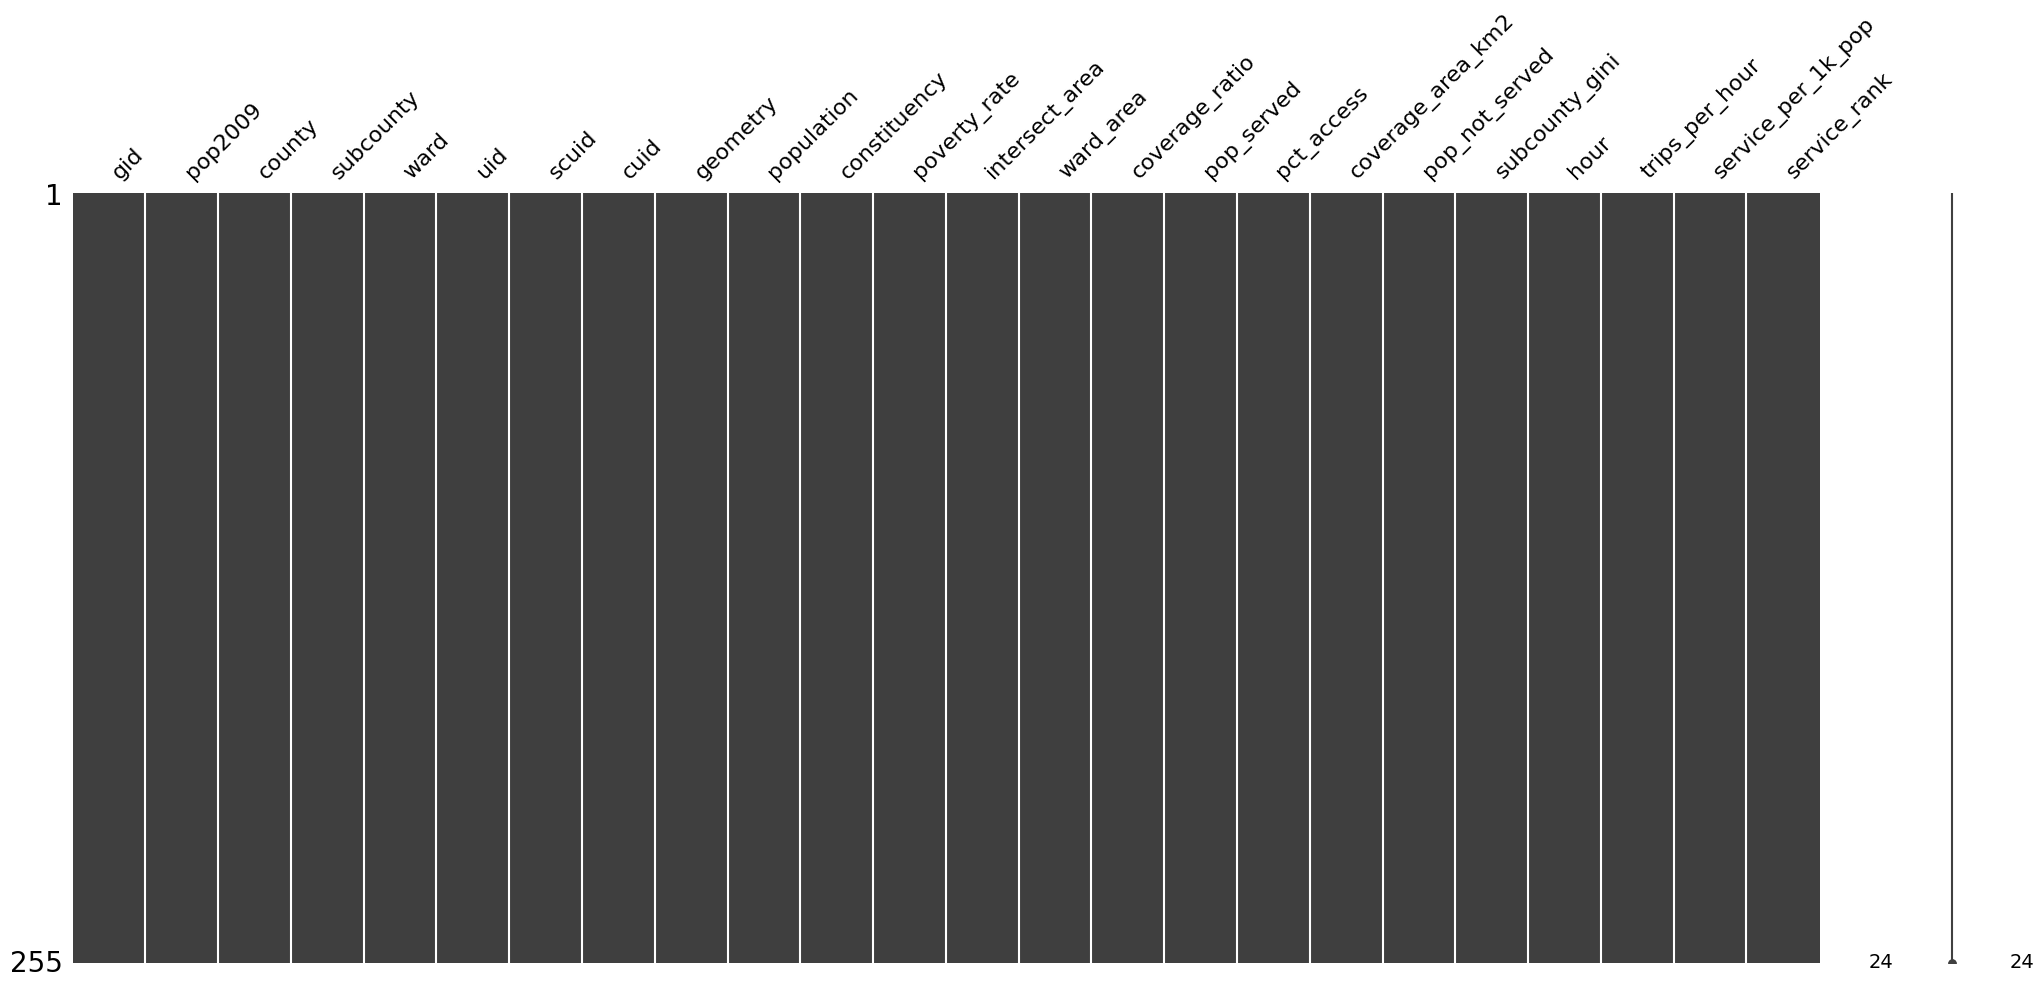

In [28]:
msno.matrix(wards_full_gdf)

Objectives: 
1. Clean the data for downstream processes
2. Add calendar for sequential analysis of the data

Create a Monday-Friday

In [29]:
import pandas as pd

# Create date range
calendar = pd.DataFrame({
    'date': pd.date_range(start='2025-10-01', end='2025-10-31', freq='D')
})

# Add day of week (0=Monday, 6=Sunday)
calendar['weekday'] = calendar['date'].dt.day_name()
calendar['is_weekend'] = calendar['weekday'].isin(['Saturday', 'Sunday'])
calendar.head()


,date,weekday,is_weekend
0,2025-10-01,Wednesday,False
1,2025-10-02,Thursday,False
2,2025-10-03,Friday,False
3,2025-10-04,Saturday,True
4,2025-10-05,Sunday,True


In [30]:
# Your original data
df = wards_full_gdf.copy()

# Add a constant key to both for merge
df['key'] = 1
calendar['key'] = 1

# Cross join
df_with_calendar = pd.merge(df, calendar, on='key').drop('key', axis=1)


In [31]:
df_with_calendar = df_with_calendar.sort_values(['ward', 'date', 'hour']).reset_index(drop=True)


Reasonable starting multipliers (apply to the weekday trips_per_hour values when you copy them to weekend dates):

Saturday: 0.6 — 0.8 (start with 0.7 as a central estimate)

Sunday: 0.4 — 0.6 (start with 0.5 as a central estimate)

Why these? Many cities show weekend service/ridership often falls in roughly the 40–80% band of weekday peaks depending on mode/area; Nairobi’s informal network is heterogeneous so these mid-range values are conservative but realistic given the literature and local notes. 
ITDP
+2

In [36]:
import numpy as np

# Assume df_with_calendar is your ward-hour-date table after the cross-join
# and has columns: 'date','weekday','trips_per_hour','ward','hour',...

df = df_with_calendar.copy()

# central estimate multipliers
sat_mult = 0.7
sun_mult = 0.5

# apply multipliers (create new column so original stays)
def apply_weekend_multiplier(row, sat_mult=0.7, sun_mult=0.5):
    wd = row['weekday']
    if wd == 'Saturday':
        return row['trips_per_hour'] * sat_mult
    elif wd == 'Sunday':
        return row['trips_per_hour'] * sun_mult
    else:
        return row['trips_per_hour']

df['trips_per_hour_adj'] = df.apply(apply_weekend_multiplier, axis=1, sat_mult=sat_mult, sun_mult=sun_mult)

# recompute normalized metrics
df['service_per_1k_pop_adj'] = df['trips_per_hour_adj'] / df['population'] * 1000
df['trips_per_person_per_hour_adj'] = df['trips_per_hour_adj'] / df['population']


Account for traffic during the weekends

In [37]:
candidates = [
    {'sat':0.6, 'sun':0.4},
    {'sat':0.7, 'sun':0.5},  # central
    {'sat':0.8, 'sun':0.6},
]

results = []
for c in candidates:
    tmp = df.copy()
    tmp['trips_per_hour_adj'] = tmp.apply(lambda r: r['trips_per_hour'] * (c['sat'] if r['weekday']=='Saturday' else (c['sun'] if r['weekday']=='Sunday' else 1.0)), axis=1)
    summary = tmp.groupby('weekday')['trips_per_hour_adj'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    results.append({'mult':c, 'weekday_means': summary.to_dict()})

# inspect results list to see how weekend means change

In [38]:
results

[{'mult': {'sat': 0.6, 'sun': 0.4},
  'weekday_means': {'Monday': 649.9294117647058,
   'Tuesday': 649.9294117647058,
   'Wednesday': 649.9294117647058,
   'Thursday': 649.9294117647058,
   'Friday': 649.9294117647058,
   'Saturday': 389.9576470588235,
   'Sunday': 259.9717647058824}},
 {'mult': {'sat': 0.7, 'sun': 0.5},
  'weekday_means': {'Monday': 649.9294117647058,
   'Tuesday': 649.9294117647058,
   'Wednesday': 649.9294117647058,
   'Thursday': 649.9294117647058,
   'Friday': 649.9294117647058,
   'Saturday': 454.9505882352941,
   'Sunday': 324.9647058823529}},
 {'mult': {'sat': 0.8, 'sun': 0.6},
  'weekday_means': {'Monday': 649.9294117647058,
   'Tuesday': 649.9294117647058,
   'Wednesday': 649.9294117647058,
   'Thursday': 649.9294117647058,
   'Friday': 649.9294117647058,
   'Saturday': 519.9435294117648,
   'Sunday': 389.9576470588235}}]

In [49]:
print(df.head(2))

    gid  pop2009   county              subcounty          ward          uid  \
0  2078  43168.0  Nairobi  Kamukunji  Sub County  Airbase Ward  t4Suo8Enc7T   
1  2078  43168.0  Nairobi  Kamukunji  Sub County  Airbase Ward  t4Suo8Enc7T   

         scuid         cuid  \
0  qoLIT7y5f5c  jkG3zaihdSs   
1  qoLIT7y5f5c  jkG3zaihdSs   

                                            geometry     population  ... hour  \
0  POLYGON ((263765.5843998674 9860350.470779378,...  105433.255157  ...    6   
1  POLYGON ((263765.5843998674 9860350.470779378,...  105433.255157  ...    9   

   trips_per_hour  service_per_1k_pop  service_rank       date    weekday  \
0          1164.0           11.040160          76.5 2025-10-01  Wednesday   
1           388.0            3.680053         156.0 2025-10-01  Wednesday   

   is_weekend  trips_per_hour_adj  service_per_1k_pop_adj  \
0       False              1164.0               11.040160   
1       False               388.0                3.680053   

   trips

In [48]:
df.to_csv('/home/dataopske/Desktop/jav/data/processed/spatio_temporal_calendar.csv', index=False)